# Simulator Experiment
This notebook displays functionalities of the simulator, in a fast modular way.

In [1]:
from pathlib import Path
import os, sys

# Ensure a common Results/ folder next to Experiments/
cwd = Path.cwd().resolve()
if cwd.name == "Experiments" and (cwd.parent / "helpers").exists():
    PROJECT_ROOT = cwd.parent
elif (cwd / "helpers").exists():
    PROJECT_ROOT = cwd
elif (cwd / "MICRO-489_SMLM_tracking" / "helpers").exists():
    PROJECT_ROOT = cwd / "MICRO-489_SMLM_tracking"
else:
    raise RuntimeError(f"Could not find project root from {cwd}")

OUT_DIR = PROJECT_ROOT / "Results"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Results directory: {OUT_DIR}")

Results directory: C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Results


In [2]:
%cd ..
from helpers.helpersGeneration import *
from helpers.helpersSimulation import *
from helpers.helpersTracking import *
from helpers.helpersStatistics import *
from helpers.helpersAssignment import *
from helpers.helpersPlotting import *

c:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking


## 1. Video generation

In [33]:
D_list = [
    (0.10, 0.30),
    (1.50, 0.15),
    (3.50, 0.10),
    (5.00, 0.20),
    (7.50, 0.10),
    (10.0, 0.15),
]

# strong anisotropic, directed motion
simulation_config = {
    "nparticles": 11,
    "nframes": 10,
    "nposframe": 10,
    "D_list": D_list,
    "dt": 1.0,
    "anisotropy_ratio_range": (0.05, 0.2),
    "theta_range": (np.deg2rad(30), np.deg2rad(30)),
    "frame_size": (128, 128),
    "intensity_mean": 650, # nphotons
    "intensity_std": 300,
    "directed_motion": True,
    "drift_speed": 0.4,
    "drift_persistence": 0.8,
    "drift_noise_std": 0.1,
}

image_config = {
    "particle_intensity": [250, 150],
    "background_intensity": [150, 150],
    "poisson_noise": 100,
    "output_size": 128,
    "upsampling_factor": 5,
    "resolution": 100e-9,
    "trajectory_unit": -1,
    "invert_y": True,
}

sim = Simulator(
    simulation_config=simulation_config,
    image_config=image_config,
    seed=40,
).run()

frames = sim.frames
trajectories_HR = sim.trajectories_HR # high-resolution trajectories with size nframes x nposframe
trajectories_GT = sim.trajectories_GT # Ground-Truth, low-resolution trajectories with size nframes
trajectories_FR = sim.trajectories_FR # low-resolution trajectories with size nframes, with diffusion data computed from GT
video = sim.video

In [34]:
animate_video(video, interval=100)

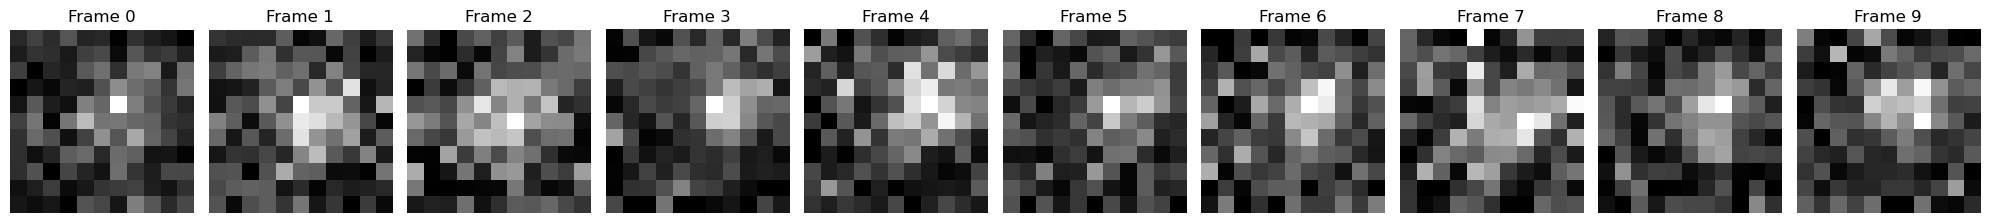

In [37]:
# extract and visualize patches
patches = extract_patches_per_id(frames, trajectories_GT, traj_id=1)
visualize_particle_patches(patches)

## Dection, Localization and Tracking

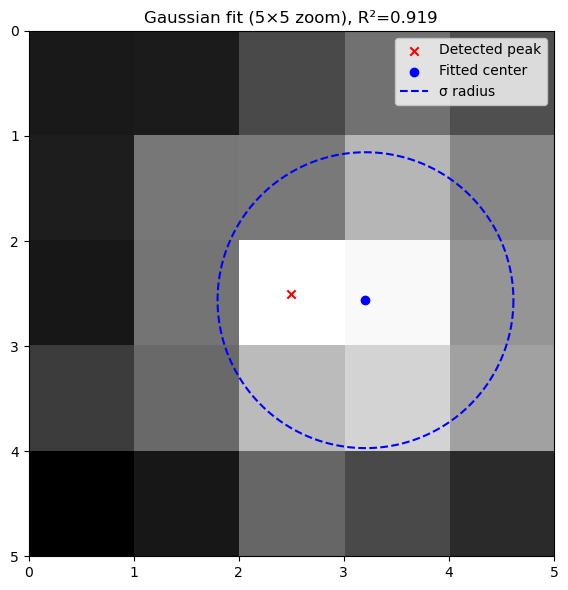

[Frame 0] Poor fit for peak at (76, 31): R-squared = 0.097 (below threshold of 0.5).
[Frame 1] Poor fit for peak at (70, 35): R-squared = 0.406 (below threshold of 0.5).
[Frame 2] Poor fit for peak at (65, 38): R-squared = 0.231 (below threshold of 0.5).
[Frame 2] Poor fit for peak at (69, 38): R-squared = 0.225 (below threshold of 0.5).
[Frame 5] Poor fit for peak at (39, 25): R-squared = 0.361 (below threshold of 0.5).
[Frame 6] Poor fit for peak at (41, 29): R-squared = 0.392 (below threshold of 0.5).
[Frame 8] Poor fit for peak at (61, 53): R-squared = 0.382 (below threshold of 0.5).
[Frame 9] Poor fit for peak at (59, 56): R-squared = 0.281 (below threshold of 0.5).
Computing assignment using algorithm: hungarian
0 -> 0
1 -> 3
2 -> -1
3 -> -1
4 -> 5
5 -> 4
6 -> 6
7 -> 2
8 -> 1
9 -> -1
10 -> 7
Trajectory ID: 0, Frames: 0->9, Number of positions: 10, Relabelled: Yes
Trajectory ID: 3, Frames: 0->4, Number of positions: 5, Relabelled: Yes
Trajectory ID: -1, Frames: 0->4, Number of pos

In [16]:
# Detect, localize and track particles
(
    trajectories_localization,
    cost_peak2peak,
    assignment_output,
    cost_traj2traj,
) = track(
    frames,
    trajectories_GT,
    mode="localization",

    # detection
    detection_threshold=None,

    # linking
    max_distance=10,
    min_length=5,
    max_gap=0,

    # stitching
    stitch_fragments=False,
    stitch_max_gap=4,
    stitch_base_distance=10.0,
    stitch_kwargs=None,
    verbose_stitching=True,

    # localization quality
    r_squared_threshold=0.5,

    # peak-to-peak assignment
    algo_peak2peak="hungarian",
    cost_func_peak2peak=None,

    # trajectory-to-trajectory assignment
    algo_traj2traj="hungarian",
    cost_func_traj2traj=None,

    # verbosity / visualization
    verbose_loc=True,
    visualization_loc=True,
    verbose_assignment=True,
)

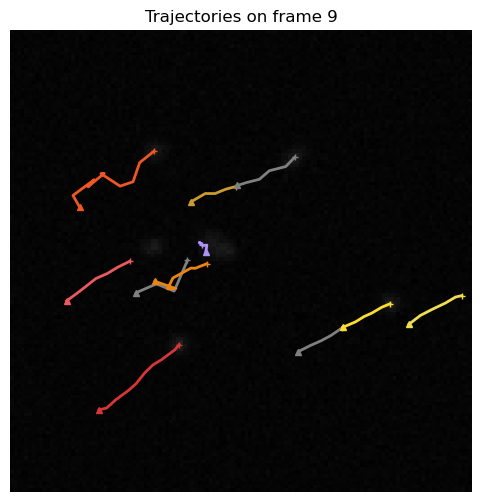

In [6]:
show_trajectories(frames, trajectories_localization, frame_id=simulation_config["nframes"]-1)

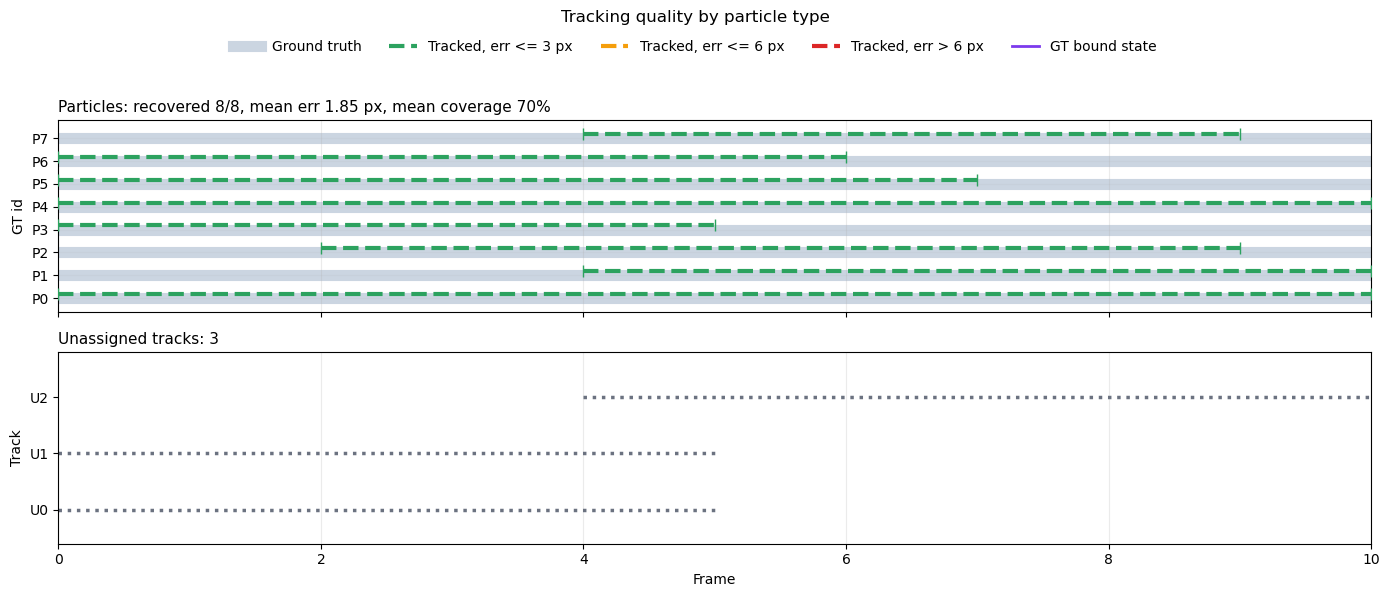

In [7]:
linear_trajectories_visualizer(trajectories_localization, trajectories_GT)

## 3. MSD and D estimation

In [12]:
MSD_list_GT = calculateMSDtrajectories(trajectories_GT)
MSD_list = calculateMSDtrajectories(trajectories_localization)

In [13]:
results = estimateDfromTrajectories(trajectories_localization)

In [14]:
diffusion_results = evaluate_diffusion(trajectories_localization, trajectories_GT, target="localization")

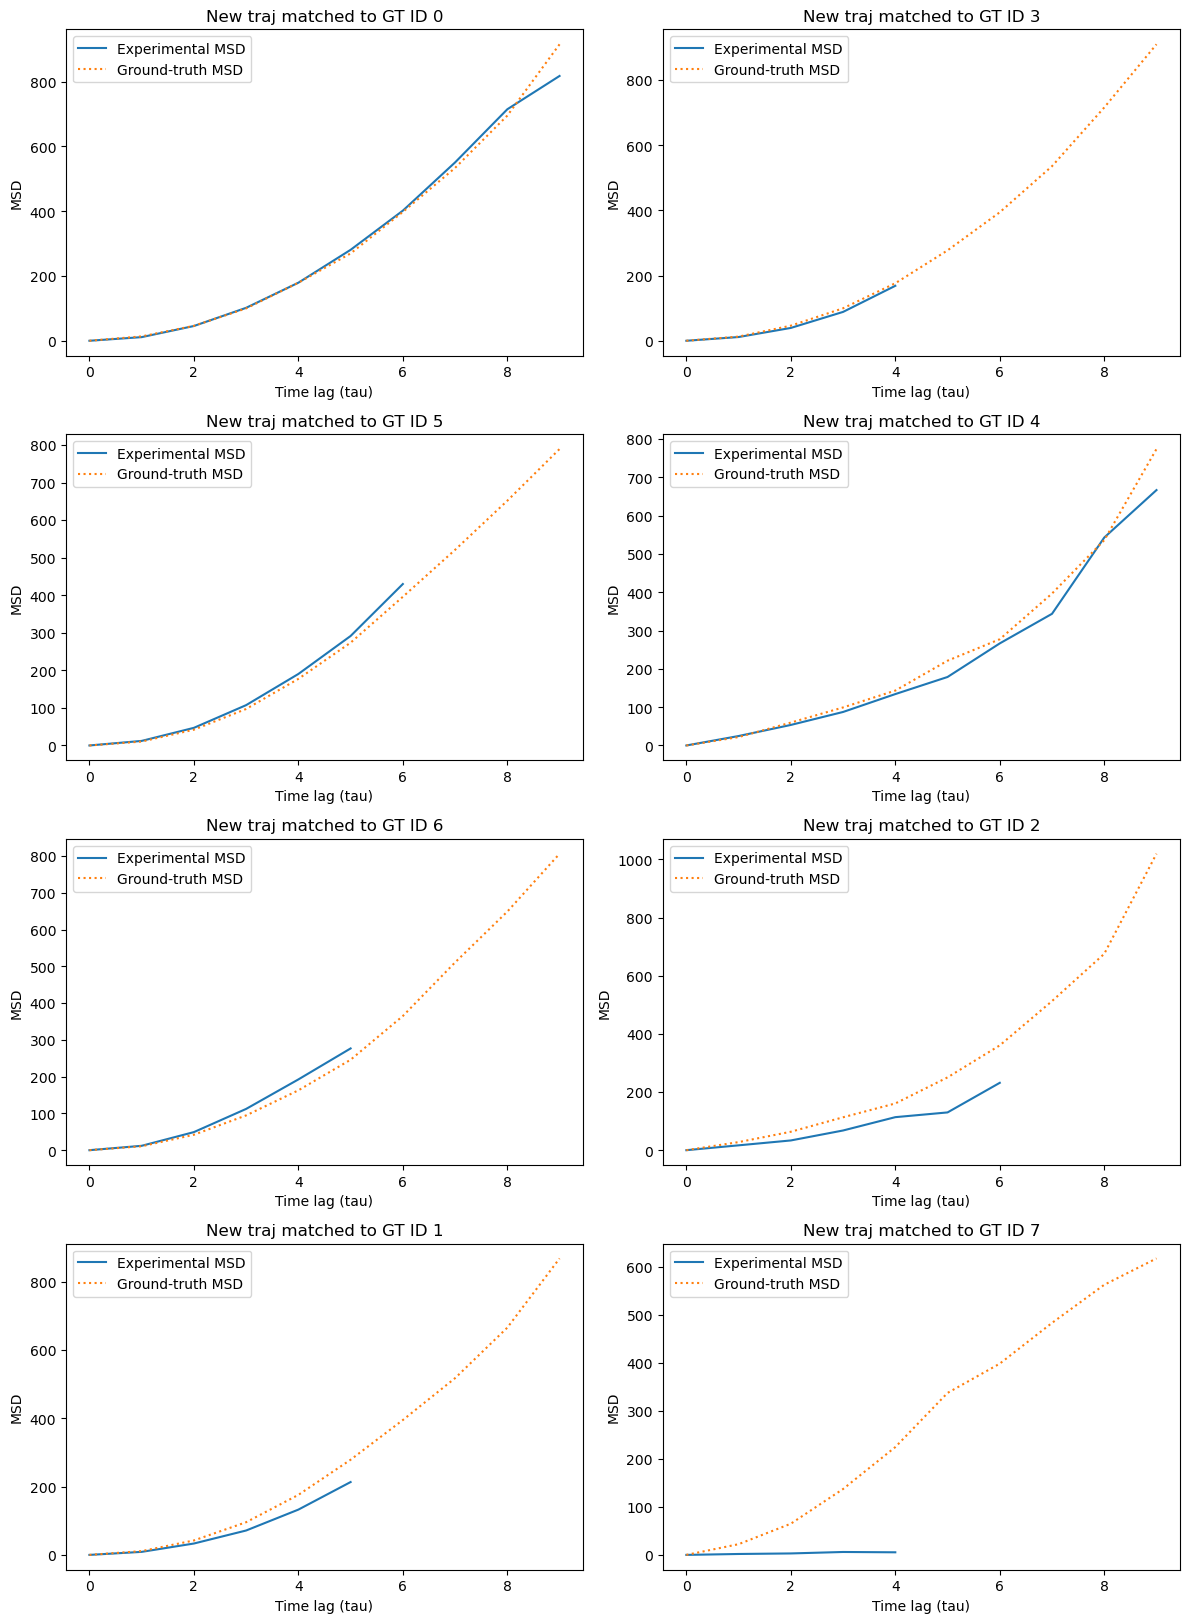

In [15]:
plotMSDvsGT(trajectories_localization, trajectories_GT)